In [1]:
###-----------------
### Import libraries
###-----------------

from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib

from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, mean_squared_error,r2_score  # Import function to calculate various metric

from collections.abc import Callable  # Type hinting callable objects/functions
from typing import Literal  # Literal type hints to restrict variable values

from sklearn.preprocessing import MinMaxScaler  # Import for standardizing features (zero mean, unit variance)

from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix, fn_plot_label# Custom utility

import tensorflow as tf

In [2]:
###----------------------
### Some basic parameters
###----------------------

inpDir = Path('..') / '..' / 'input'
outDir = Path('..') / 'output'
modelDir = Path('..') / 'models'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
tf.random.set_seed(RANDOM_STATE) # setting for Tensorflow as well

TEST_SIZE = 0.2

ALPHA = 0.001
EPOCHS = 100# number of cycles to run
PATIENCE = 20
LR_PATIENCE = 15
FACTOR_LR = 0.1
BATCH_SIZE = 32 # inline of Training Rows being 60000
IMG_HEIGHT = 190
IMG_WIDTH = 190
LR_FACTOR  = 0.1
MIN_LR = 1e-5

# Set parameters for decoration of plots
params = {'legend.fontsize' : 'large',
          'figure.figsize'  : (15,10),
          'axes.labelsize'  : 'x-large',
          'axes.titlesize'  :'x-large',
          'xtick.labelsize' :'large',
          'ytick.labelsize' :'large',
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params) # update rcParams

plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

<h1>
    Getting Data
</h1>

In [3]:
data_df = pd.read_csv('../datasets/dnn_input/housing/household_power_consumption.txt',
                      sep=';',
                      na_values=['nan','?'])
data_df

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0
...,...,...,...,...,...,...,...,...,...
2075254,26/11/2010,20:58:00,0.946,0.000,240.43,4.0,0.0,0.0,0.0
2075255,26/11/2010,20:59:00,0.944,0.000,240.00,4.0,0.0,0.0,0.0
2075256,26/11/2010,21:00:00,0.938,0.000,239.82,3.8,0.0,0.0,0.0
2075257,26/11/2010,21:01:00,0.934,0.000,239.70,3.8,0.0,0.0,0.0


In [4]:
data_df['dt'] = pd.to_datetime(data_df['Date'] + ' ' + data_df['Time'],dayfirst=True)
data_df = data_df.set_index('dt',drop=True)
data_df = data_df.drop(['Date','Time'],axis = 1)
data_df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
data_df = data_df.fillna(data_df.mean())
df_resample = data_df.resample('h').mean()
df_resample.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667


In [6]:
df_resample['target'] = df_resample['Global_active_power'].shift(-1)
df_resample = df_resample.dropna()
df_resample.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,target
dt,,,,,,,,
2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,3.632200
2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,3.400233
2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,3.268567
2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,3.056467
2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,2.200133


In [7]:
split = 365*24

train_df = df_resample.iloc[:split]
test_df = df_resample.iloc[split:]

df_resample.shape,train_df.shape,test_df.shape


((34588, 8), (8760, 8), (25828, 8))

In [8]:
y_train = train_df['target'].to_numpy()
y_test = test_df['target'].to_numpy()

train_feat_df = train_df.drop('target',axis = 1)
test_feat_df = test_df.drop('target',axis = 1)


train_feat_df.shape,test_feat_df.shape

((8760, 7), (25828, 7))

In [9]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(train_feat_df)
X_test = scaler.transform(test_feat_df)

X_train.shape,X_test.shape

((8760, 7), (25828, 7))

In [10]:
#converting Xdatas t -> batch * timestamp * features

X_train = X_train.reshape(X_train.shape[0],1,X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0],1,X_test.shape[1])

X_train.shape,X_test.shape

((8760, 1, 7), (25828, 1, 7))

<h1>Model Declaration</h1>

In [14]:
model = tf.keras.Sequential()

init = tf.keras.initializers.HeNormal()

model.add(tf.keras.Input(shape=(X_train.shape[1],X_train.shape[2])))
model.add(tf.keras.layers.LSTM(512,activation='tanh',kernel_initializer=init))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(128,activation = 'relu'))
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(1,activation = 'linear'))


In [15]:
metrics =tf.keras.metrics.RootMeanSquaredError()#metrics
loss_fn = tf.keras.losses.MeanSquaredError() #loss function
optimizer = tf.keras.optimizers.Adam(learning_rate = ALPHA) #optimizer

<h1>Training Model</h1>

In [16]:
metrics =tf.keras.metrics.RootMeanSquaredError()#metrics
loss_fn = tf.keras.losses.MeanSquaredError() #loss function
optimizer = tf.keras.optimizers.Adam(learning_rate = ALPHA) #optimizer

In [17]:
model.compile(optimizer = optimizer,
             loss = loss_fn,
             metrics = [metrics])

In [18]:
history = model.fit(X_train,y_train,
                    validation_data=[X_test,y_test],
                    batch_size=BATCH_SIZE,
                    epochs=EPOCHS)

Epoch 1/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.4833 - root_mean_squared_error: 0.6952 - val_loss: 0.3550 - val_root_mean_squared_error: 0.5958
Epoch 2/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.4582 - root_mean_squared_error: 0.6769 - val_loss: 0.3471 - val_root_mean_squared_error: 0.5891
Epoch 3/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.4446 - root_mean_squared_error: 0.6668 - val_loss: 0.3489 - val_root_mean_squared_error: 0.5907
Epoch 4/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.4445 - root_mean_squared_error: 0.6667 - val_loss: 0.3521 - val_root_mean_squared_error: 0.5934
Epoch 5/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.4429 - root_mean_squared_error: 0.6655 - val_loss: 0.3541 - val_root_mean_squared_error: 0.5951
Epoch 6/100
274/274 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.4414 - root_mean_squared_error: 0.6644 - val_loss: 0.3494 - val_root_mean_squared_error: 0.5911
Epoch 7/100
274/274 ━━━━━━━━━━━━━━━━━━━━

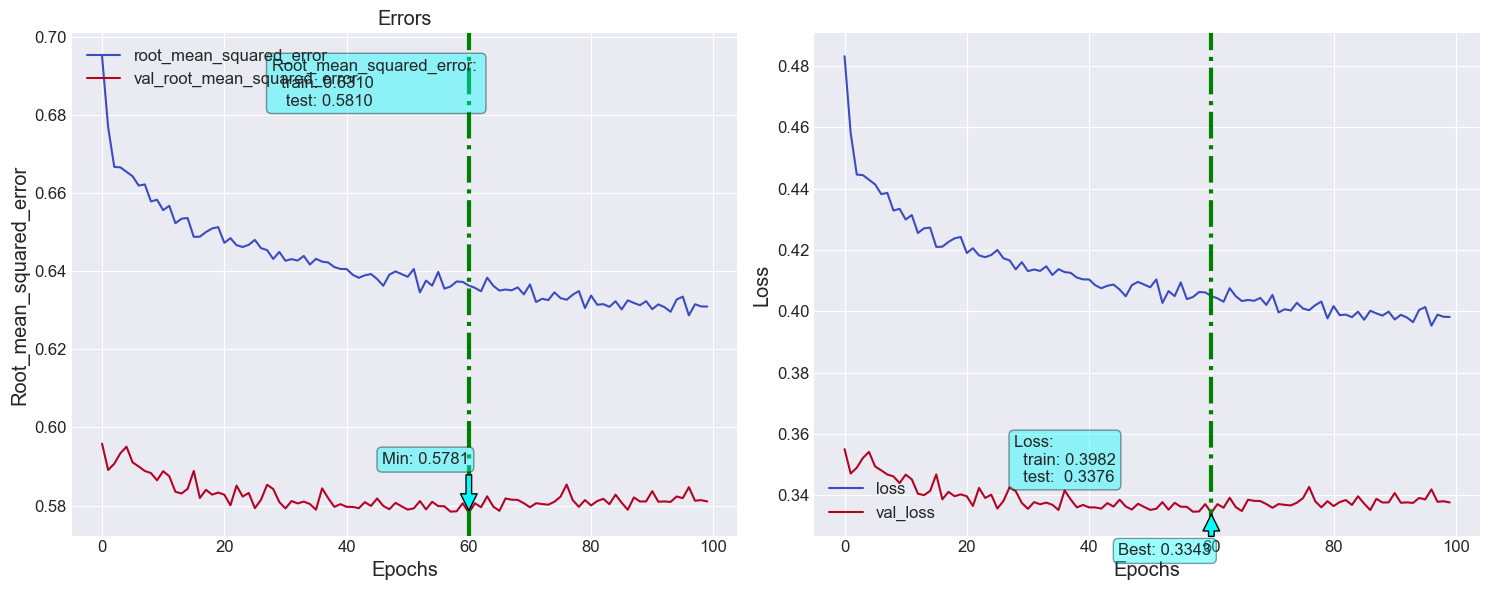

In [19]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

<h1>Prediction</h1>